In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_selection import chi2
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import silhouette_score


import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')

In [3]:
df_cleaned = df.copy()

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df_cleaned

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0


In [6]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [7]:
df_cleaned.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [8]:
df_cleaned.duplicated().sum()

np.int64(0)

In [9]:
df_cleaned.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [10]:
df_cleaned['Income'].fillna(df_cleaned['Income'].median(), inplace=True)

In [11]:
df_cleaned.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

# FEATURE ENGINEERING

In [12]:
df_cleaned.drop(['ID', 'Z_CostContact', 'Z_Revenue'], axis = 1, inplace = True)

In [13]:
df_cleaned['Dt_Customer'] = pd.to_datetime(df_cleaned['Dt_Customer'], format = "%d-%m-%Y")
df_cleaned['age'] = 2014 - df_cleaned['Year_Birth']

In [14]:
df_cleaned.drop('Year_Birth', axis = 1, inplace = True)

In [15]:
df_cleaned['children'] = df_cleaned['Kidhome'] + df_cleaned['Teenhome']

In [16]:
df_cleaned.drop(['Kidhome', 'Teenhome'], axis = 1, inplace = True)

In [17]:
df_cleaned['family_size'] = np.where(df_cleaned['Marital_Status'].isin(['Married', 'Together']), df_cleaned['children'] + 2, df_cleaned['children'] + 1)

In [18]:
df_cleaned['is_parent'] = np.where(df_cleaned['children'] > 0, 1, 0)

In [19]:
last_date = df_cleaned['Dt_Customer'].max()
df_cleaned['customer_tenure'] = (last_date - df_cleaned['Dt_Customer']).dt.days

In [20]:
df_cleaned['total_spent'] = (
    df_cleaned['MntWines'] +
    df_cleaned['MntFruits'] +
    df_cleaned['MntMeatProducts'] +
    df_cleaned['MntFishProducts'] +
    df_cleaned['MntSweetProducts'] +
    df_cleaned['MntGoldProds']
)

In [21]:
df_cleaned['total_purchases'] = (
    df_cleaned['NumWebPurchases'] +
    df_cleaned['NumCatalogPurchases'] +
    df_cleaned['NumStorePurchases']
)

In [22]:
df_cleaned['total_campaign_acceptance'] = (
    df_cleaned['AcceptedCmp1'] +
    df_cleaned['AcceptedCmp2'] +
    df_cleaned['AcceptedCmp3'] +
    df_cleaned['AcceptedCmp4'] +
    df_cleaned['AcceptedCmp5']
)

In [23]:
df_cleaned['avg_spend_per_purchase'] = (
    df_cleaned['total_spent'] /
    (df_cleaned['total_purchases'] + 1)
)

In [24]:
df_cleaned['income_per_person'] = (
    df_cleaned['Income'] /
    df_cleaned['family_size']
)

In [25]:
df_cleaned['web_purchase_ratio'] = (
    df_cleaned['NumWebPurchases'] /
    (df_cleaned['total_purchases'] + 1)
)

In [26]:
df_cleaned.head()

,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,age,children,family_size,is_parent,customer_tenure,total_spent,total_purchases,total_campaign_acceptance,avg_spend_per_purchase,income_per_person,web_purchase_ratio
0,Graduation,Single,58138.0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,57,0,1,0,663,1617,22,0,70.304348,58138.0,0.347826
1,Graduation,Single,46344.0,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,60,2,3,1,113,27,4,0,5.400000,15448.0,0.200000
2,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,49,0,2,0,312,776,20,0,36.952381,35806.5,0.380952
3,Graduation,Together,26646.0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,30,1,3,1,139,53,6,0,7.571429,8882.0,0.285714
4,PhD,Married,58293.0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,33,1,3,1,161,422,14,0,28.133333,19431.0,0.333333


In [27]:
df_cleaned.isnull().sum()

Education                    0
Marital_Status               0
Income                       0
Dt_Customer                  0
Recency                      0
MntWines                     0
MntFruits                    0
MntMeatProducts              0
MntFishProducts              0
MntSweetProducts             0
MntGoldProds                 0
NumDealsPurchases            0
NumWebPurchases              0
NumCatalogPurchases          0
NumStorePurchases            0
NumWebVisitsMonth            0
AcceptedCmp3                 0
AcceptedCmp4                 0
AcceptedCmp5                 0
AcceptedCmp1                 0
AcceptedCmp2                 0
Complain                     0
Response                     0
age                          0
children                     0
family_size                  0
is_parent                    0
customer_tenure              0
total_spent                  0
total_purchases              0
total_campaign_acceptance    0
avg_spend_per_purchase       0
income_p

In [28]:
df_cleaned.columns

Index(['Education', 'Marital_Status', 'Income', 'Dt_Customer', 'Recency',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'age',
       'children', 'family_size', 'is_parent', 'customer_tenure',
       'total_spent', 'total_purchases', 'total_campaign_acceptance',
       'avg_spend_per_purchase', 'income_per_person', 'web_purchase_ratio'],
      dtype='object')

# EDA

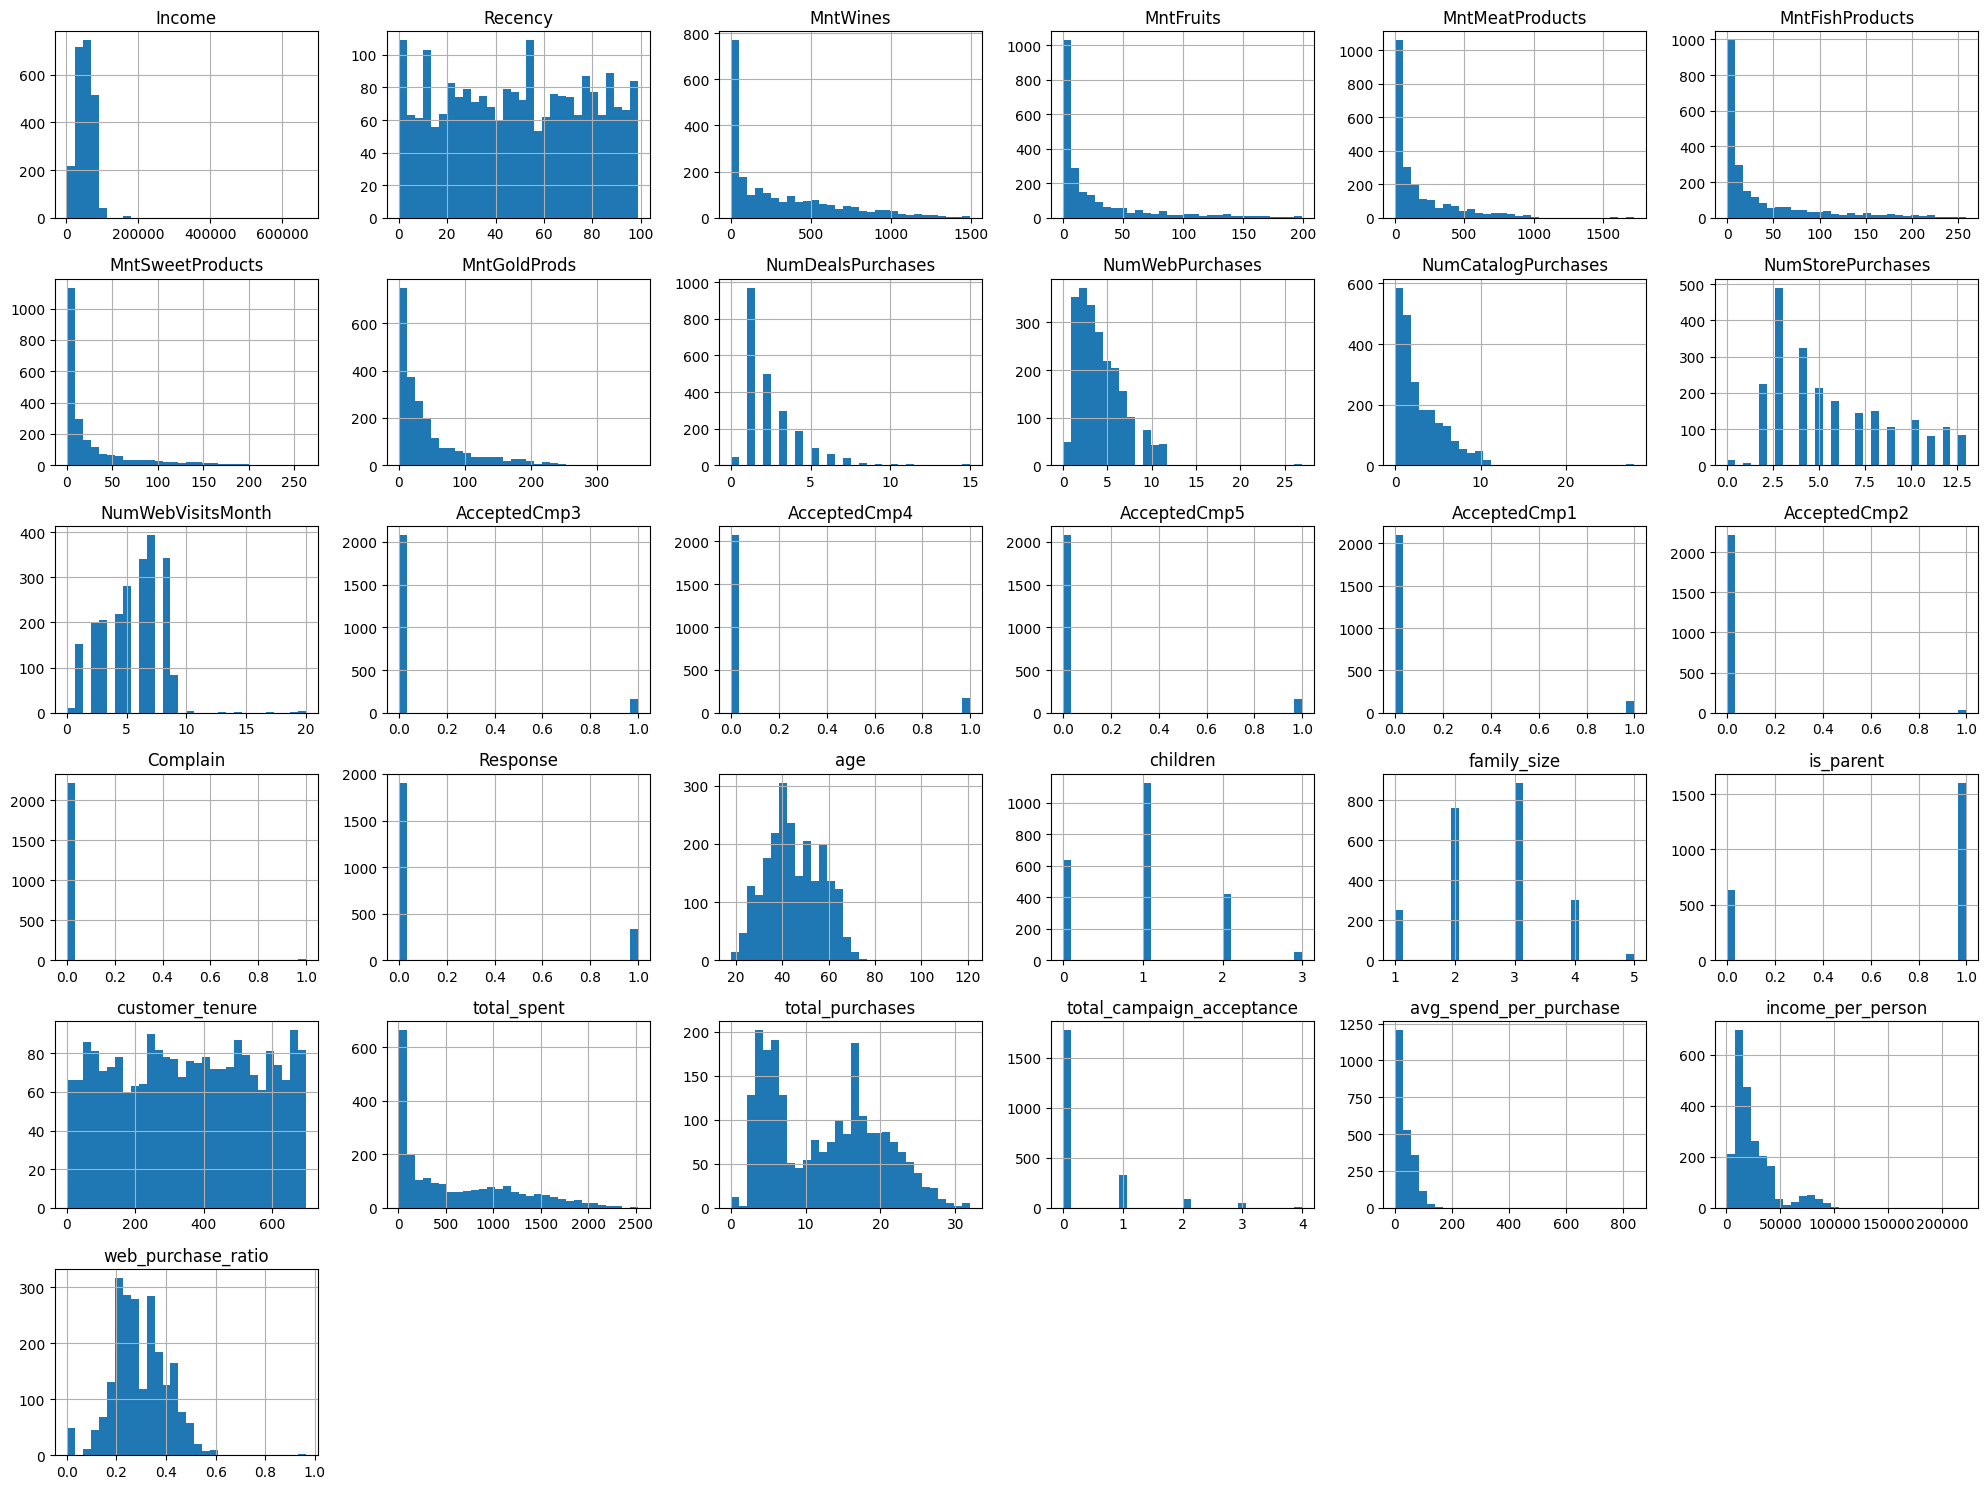

In [29]:
num_cols = df_cleaned.select_dtypes(include=['int64','float64']).columns

df_cleaned[num_cols].hist(figsize=(20,15), bins=30)
plt.tight_layout()
plt.show()

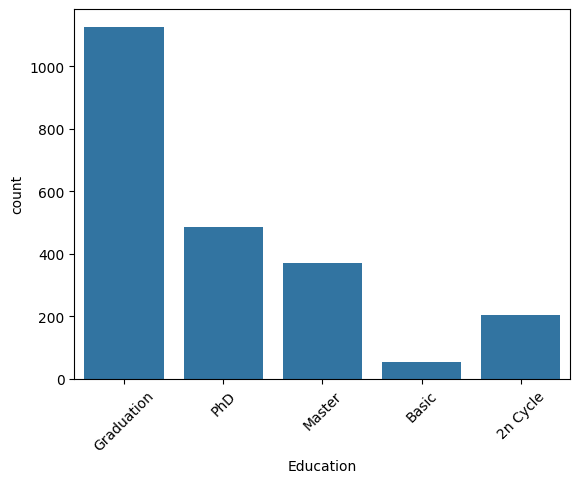

In [30]:
sns.countplot(data=df_cleaned,x='Education')
plt.xticks(rotation=45)
plt.show()

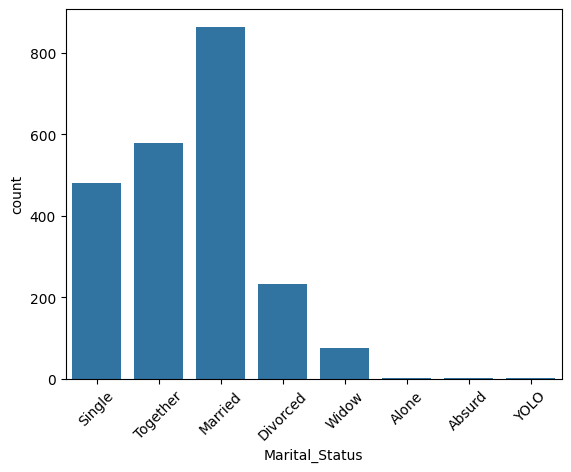

In [31]:
sns.countplot(data=df_cleaned,x='Marital_Status')
plt.xticks(rotation=45)
plt.show()

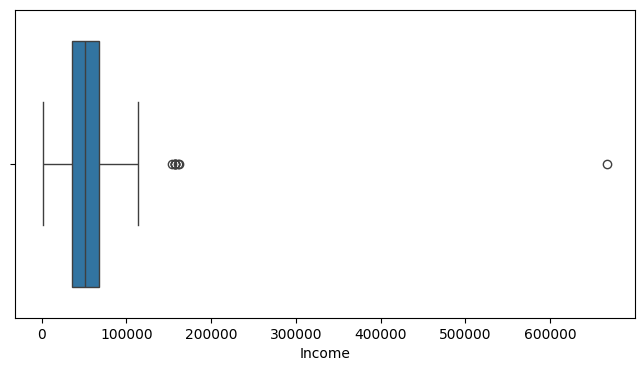

In [32]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_cleaned['Income'])
plt.show()

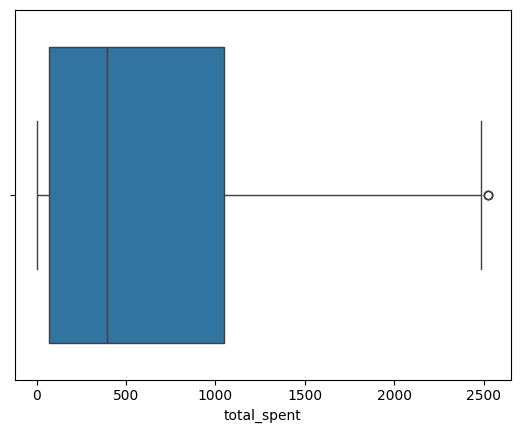

In [33]:
sns.boxplot(x=df_cleaned['total_spent'])
plt.show()

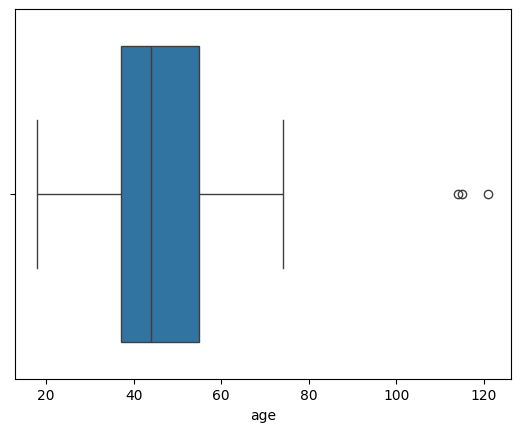

In [34]:
sns.boxplot(x=df_cleaned['age'])
plt.show()

In [35]:
df_cleaned[df_cleaned['age'] > 90]['age']

192    114
239    121
339    115
Name: age, dtype: int64

In [36]:
df_cleaned = df_cleaned[df_cleaned['age'] < 100]

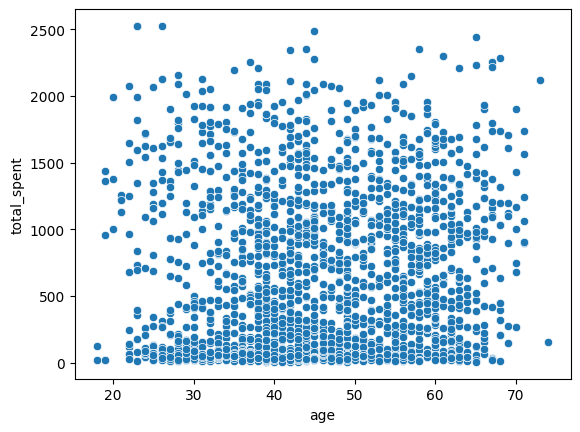

In [37]:
sns.scatterplot(
    x='age',
    y='total_spent',
    data=df_cleaned
)
plt.show()

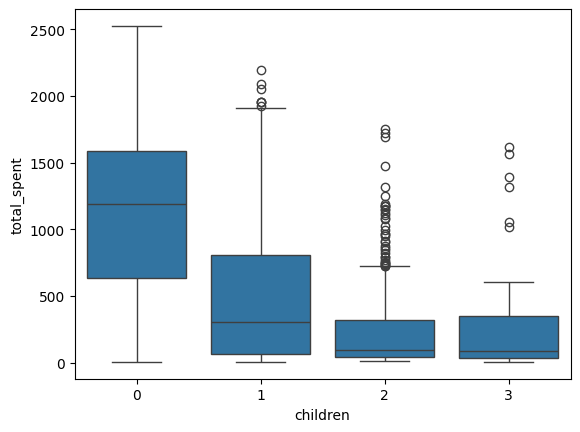

In [38]:
sns.boxplot(
    x='children',
    y='total_spent',
    data=df_cleaned
)
plt.show()

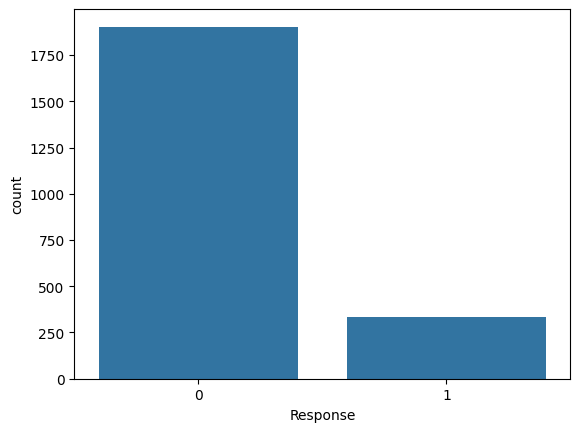

Response
0    85.069289
1    14.930711
Name: proportion, dtype: float64

In [39]:
sns.countplot(x='Response',data=df_cleaned)
plt.show()

df_cleaned['Response'].value_counts(normalize=True)*100

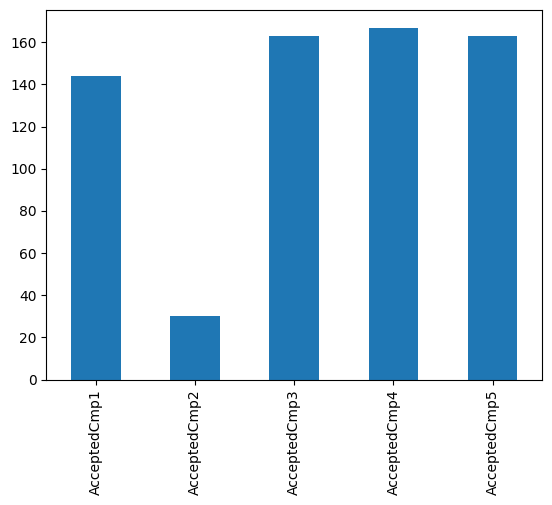

In [40]:
campaigns = [
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5'
]

df[campaigns].sum().plot(kind='bar')
plt.show()

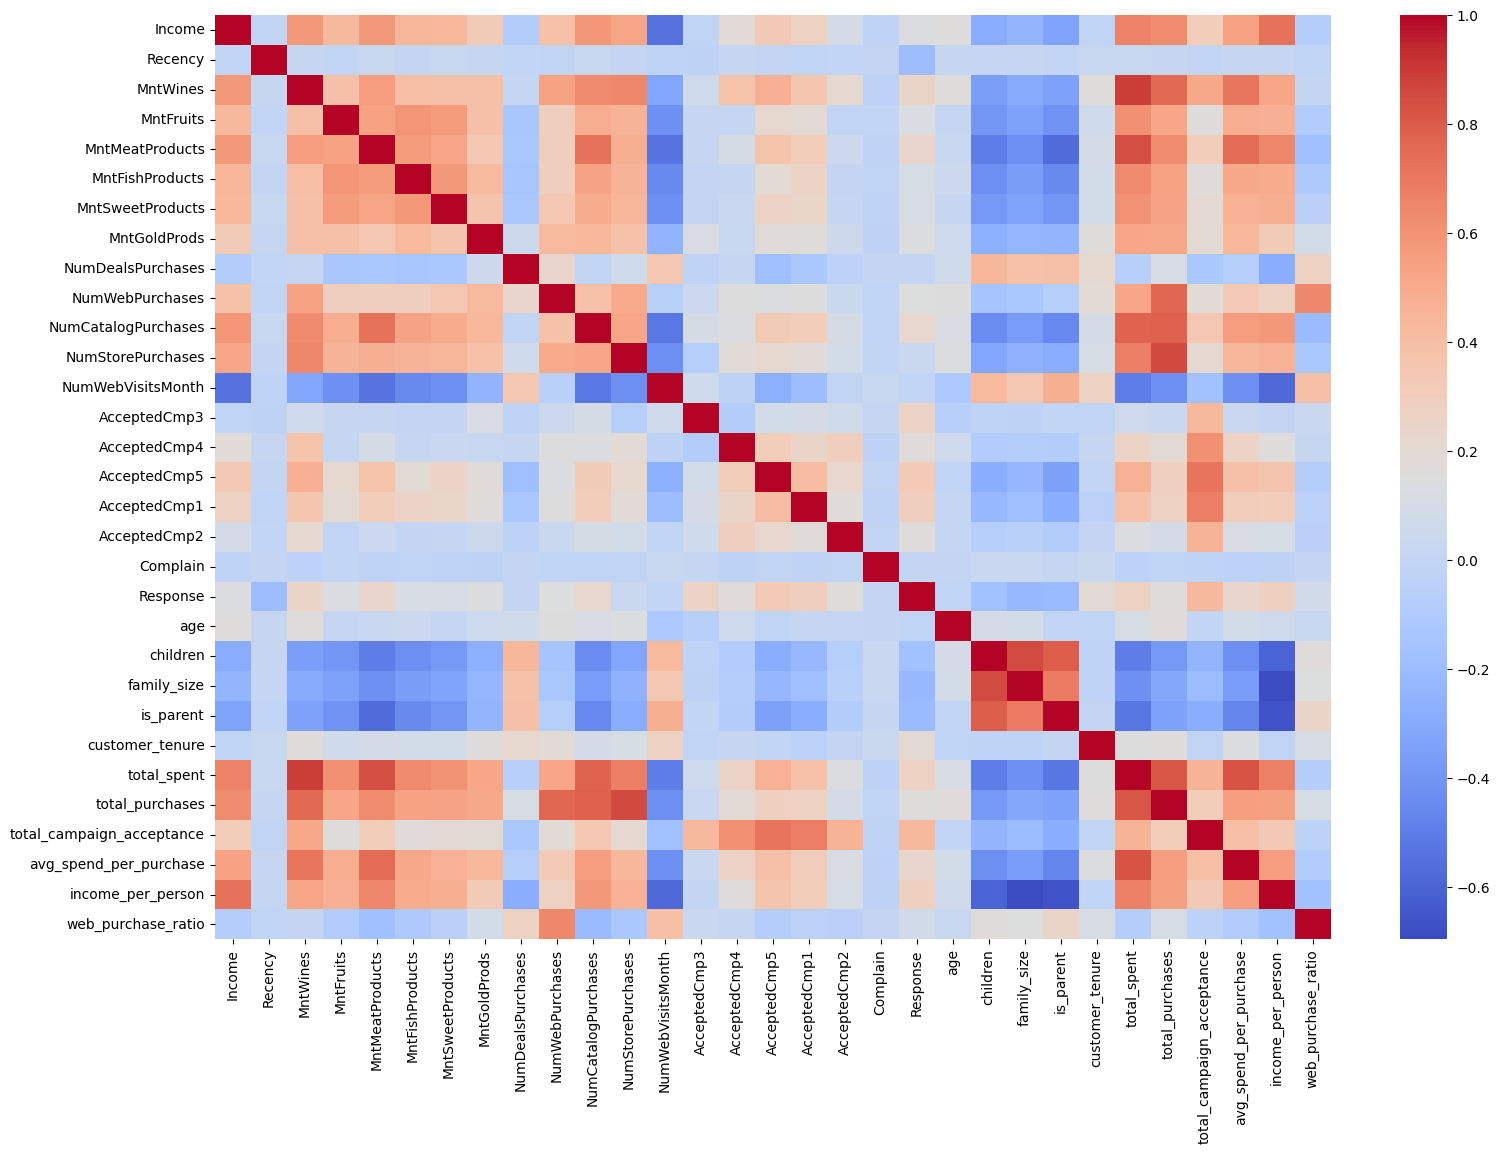

In [41]:
plt.figure(figsize=(18,12))

sns.heatmap(
    df_cleaned.select_dtypes(include=np.number).corr(),
    cmap='coolwarm'
)

plt.show()

In [42]:
corr = df_cleaned.corr(numeric_only=True)['Response']

corr.sort_values(ascending=False)

Response                     1.000000
total_campaign_acceptance    0.426253
AcceptedCmp5                 0.328182
AcceptedCmp1                 0.293882
income_per_person            0.282335
total_spent                  0.265726
AcceptedCmp3                 0.254144
MntWines                     0.247392
MntMeatProducts              0.236640
avg_spend_per_purchase       0.225745
NumCatalogPurchases          0.220894
customer_tenure              0.194187
AcceptedCmp4                 0.176890
AcceptedCmp2                 0.169249
total_purchases              0.164408
NumWebPurchases              0.148453
MntGoldProds                 0.140693
Income                       0.133121
MntFruits                    0.125904
MntSweetProducts             0.117366
MntFishProducts              0.111415
web_purchase_ratio           0.077693
NumStorePurchases            0.038855
NumDealsPurchases            0.001854
Complain                     0.000185
NumWebVisitsMonth           -0.004449
age         

# UNSUPERVISED LEARNING

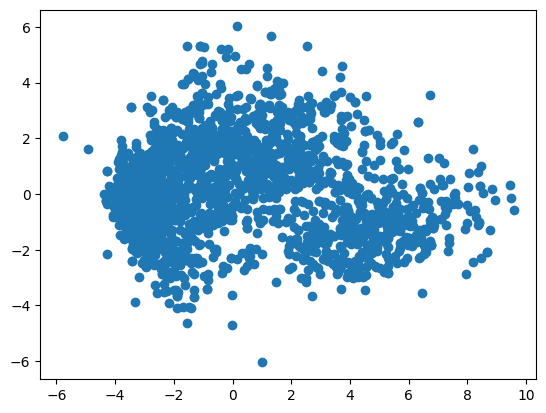

In [43]:
X = df_cleaned.select_dtypes(include=np.number)

scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled)

plt.scatter(
    pca_data[:,0],
    pca_data[:,1]
)

plt.show()

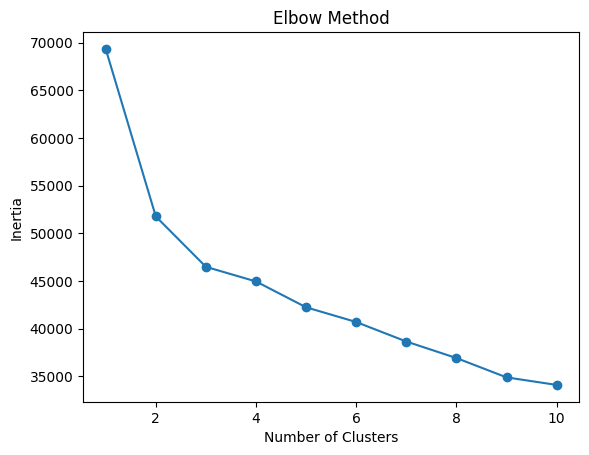

In [44]:
inertia = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(scaled)

    inertia.append(kmeans.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [45]:


for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)

    labels = kmeans.fit_predict(scaled)

    score = silhouette_score(scaled, labels)

    print(f"K={k}: {score:.3f}")

K=2: 0.291
K=3: 0.205
K=4: 0.095
K=5: 0.104
K=6: 0.091
K=7: 0.095
K=8: 0.109
K=9: 0.114
K=10: 0.108


In [46]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_cleaned['Cluster'] = kmeans.fit_predict(scaled)

In [47]:
df_cleaned['Cluster'] = df_cleaned['Cluster'].map({
    0: "Low Value",
    1: "VIP",
    2: "Regular"
})

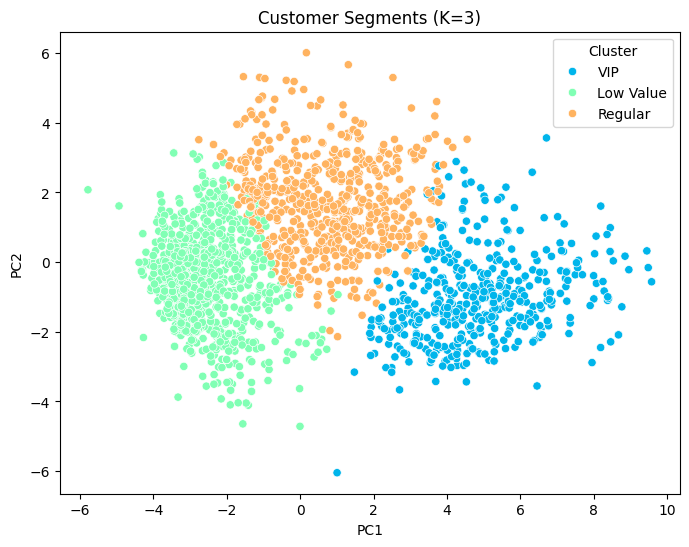

In [48]:
plt.figure(figsize=(8,6))

sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], hue=df_cleaned['Cluster'], palette = "rainbow")

plt.title("Customer Segments (K=3)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [49]:
cluster_profile = df_cleaned.groupby('Cluster').mean(numeric_only=True)

cluster_profile[['Income', 'age', 'family_size', 'total_spent', 'total_purchases', 'web_purchase_ratio', 'total_campaign_acceptance']]

,Income,age,family_size,total_spent,total_purchases,web_purchase_ratio,total_campaign_acceptance
Cluster,,,,,,,
Low Value,35781.711592,42.945722,2.897884,106.120515,6.114075,0.287140,0.083717
Regular,59703.031061,48.559091,2.795455,816.669697,18.242424,0.350102,0.237879
VIP,78640.795918,45.212245,1.657143,1429.985714,19.132653,0.239377,0.853061


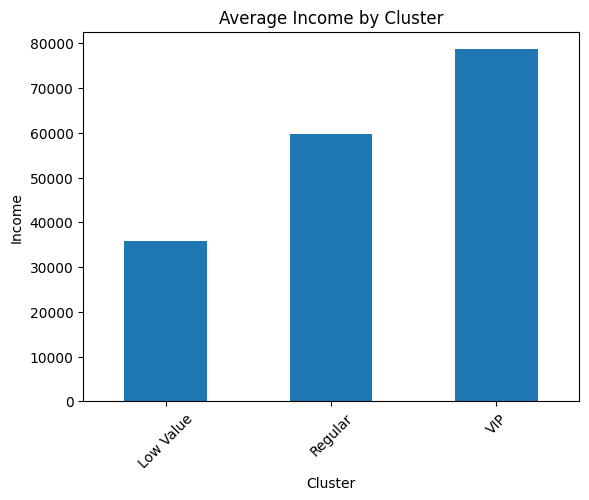

In [50]:
cluster_profile['Income'].plot(kind='bar')

plt.title("Average Income by Cluster")
plt.ylabel("Income")
plt.xticks(rotation=45)
plt.show()

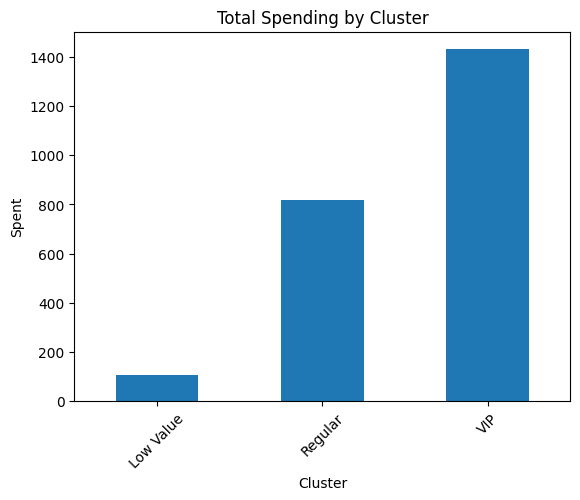

In [51]:
cluster_profile['total_spent'].plot(kind='bar')

plt.title("Total Spending by Cluster")
plt.ylabel("Spent")
plt.xticks(rotation=45)
plt.show()

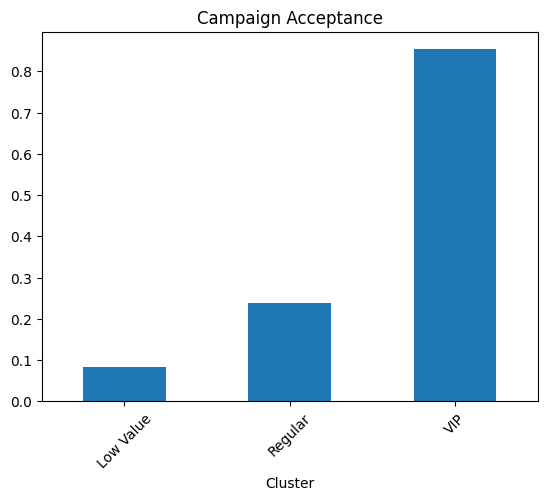

In [52]:
cluster_profile['total_campaign_acceptance'].plot(kind='bar')

plt.title("Campaign Acceptance")
plt.xticks(rotation=45)
plt.show()

# Customer Segmentation using K-Means Clustering

## Cluster Analysis

The K-Means clustering algorithm segmented the customers into three distinct groups based on their purchasing behavior, income, spending patterns, and campaign responses.

### Cluster 0 – Low-Value Customers

**Characteristics:**
- Lowest average income (~35,782)
- Lowest total spending (~106)
- Lowest number of purchases
- Low campaign acceptance rate (8.37%)
- Larger average family size

**Business Insights:**
These customers have limited purchasing power and rarely respond to marketing campaigns. They are price-sensitive and tend to make fewer purchases.

**Marketing Recommendations:**
- Offer discounts and coupons.
- Send promotional SMS and email campaigns.
- Introduce budget-friendly products.
- Encourage repeat purchases through cashback offers.

---

### Cluster 1 – High-Value Customers

**Characteristics:**
- Highest average income (~78,641)
- Highest total spending (~1,430)
- Highest number of purchases
- Highest campaign acceptance rate (85.3%)
- Smaller family size

**Business Insights:**
These are premium customers who generate the highest revenue. They actively respond to marketing campaigns and are the most valuable customer segment.

**Marketing Recommendations:**
- Provide VIP membership programs.
- Offer exclusive and premium products.
- Give early access to new product launches.
- Reward loyalty through personalized incentives.

---

### Cluster 2 – Moderate-Value Customers

**Characteristics:**
- Moderate income (~59,703)
- Moderate to high spending (~817)
- High purchase frequency
- Highest web purchase ratio
- Moderate campaign acceptance rate (23.8%)

**Business Insights:**
These customers frequently purchase products, especially through online channels. They have the potential to become high-value customers with personalized marketing strategies.

**Marketing Recommendations:**
- Recommend products based on purchase history.
- Send personalized email campaigns.
- Promote cross-selling and upselling offers.
- Encourage participation in loyalty programs.

---

## Conclusion

The K-Means clustering algorithm successfully divided customers into three meaningful segments. Each segment exhibits distinct purchasing behavior and campaign response patterns. These insights can help businesses develop targeted marketing strategies, improve customer engagement, and maximize campaign effectiveness.

# SUPERVISED LEARNING

In [53]:
X = df_cleaned.drop(columns=["Response"])
y = df_cleaned["Response"]

In [54]:
X

,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,age,children,family_size,is_parent,customer_tenure,total_spent,total_purchases,total_campaign_acceptance,avg_spend_per_purchase,income_per_person,web_purchase_ratio,Cluster
0,Graduation,Single,58138.0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,57,0,1,0,663,1617,22,0,70.304348,58138.000000,0.347826,VIP
1,Graduation,Single,46344.0,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,60,2,3,1,113,27,4,0,5.400000,15448.000000,0.200000,Low Value
2,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,49,0,2,0,312,776,20,0,36.952381,35806.500000,0.380952,Regular
3,Graduation,Together,26646.0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,30,1,3,1,139,53,6,0,7.571429,8882.000000,0.285714,Low Value
4,PhD,Married,58293.0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,33,1,3,1,161,422,14,0,28.133333,19431.000000,0.333333,Regular
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduation,Married,61223.0,2013-06-13,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,47,1,3,1,381,1341,16,0,78.882353,20407.666667,0.529412,Regular
2236,PhD,Together,64014.0,2014-06-10,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,68,3,5,1,19,444,15,1,27.750000,12802.800000,0.500000,Regular
2237,Graduation,Divorced,56981.0,2014-01-25,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,33,0,1,0,155,1241,18,1,65.315789,56981.000000,0.105263,VIP
2238,Master,Together,69245.0,2014-01-24,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,58,1,3,1,156,843,21,0,38.318182,23081.666667,0.272727,Regular


In [55]:
X = X.drop(columns=["Dt_Customer", "Cluster"], axis =1)

In [56]:
cat_features = [
    "Education",
    "Marital_Status",
]

In [57]:
X = pd.get_dummies(
    X,
    columns=cat_features,
    drop_first=True
)

In [58]:
X.head()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,age,children,family_size,is_parent,customer_tenure,total_spent,total_purchases,total_campaign_acceptance,avg_spend_per_purchase,income_per_person,web_purchase_ratio,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,58138.0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,57,0,1,0,663,1617,22,0,70.304348,58138.0,0.347826,False,True,False,False,False,False,False,True,False,False,False
1,46344.0,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,60,2,3,1,113,27,4,0,5.400000,15448.0,0.200000,False,True,False,False,False,False,False,True,False,False,False
2,71613.0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,49,0,2,0,312,776,20,0,36.952381,35806.5,0.380952,False,True,False,False,False,False,False,False,True,False,False
3,26646.0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,30,1,3,1,139,53,6,0,7.571429,8882.0,0.285714,False,True,False,False,False,False,False,False,True,False,False
4,58293.0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,33,1,3,1,161,422,14,0,28.133333,19431.0,0.333333,False,False,False,True,False,False,True,False,False,False,False


In [59]:
bool_cols = X.select_dtypes("bool").columns

X[bool_cols] = X[bool_cols].astype(int)

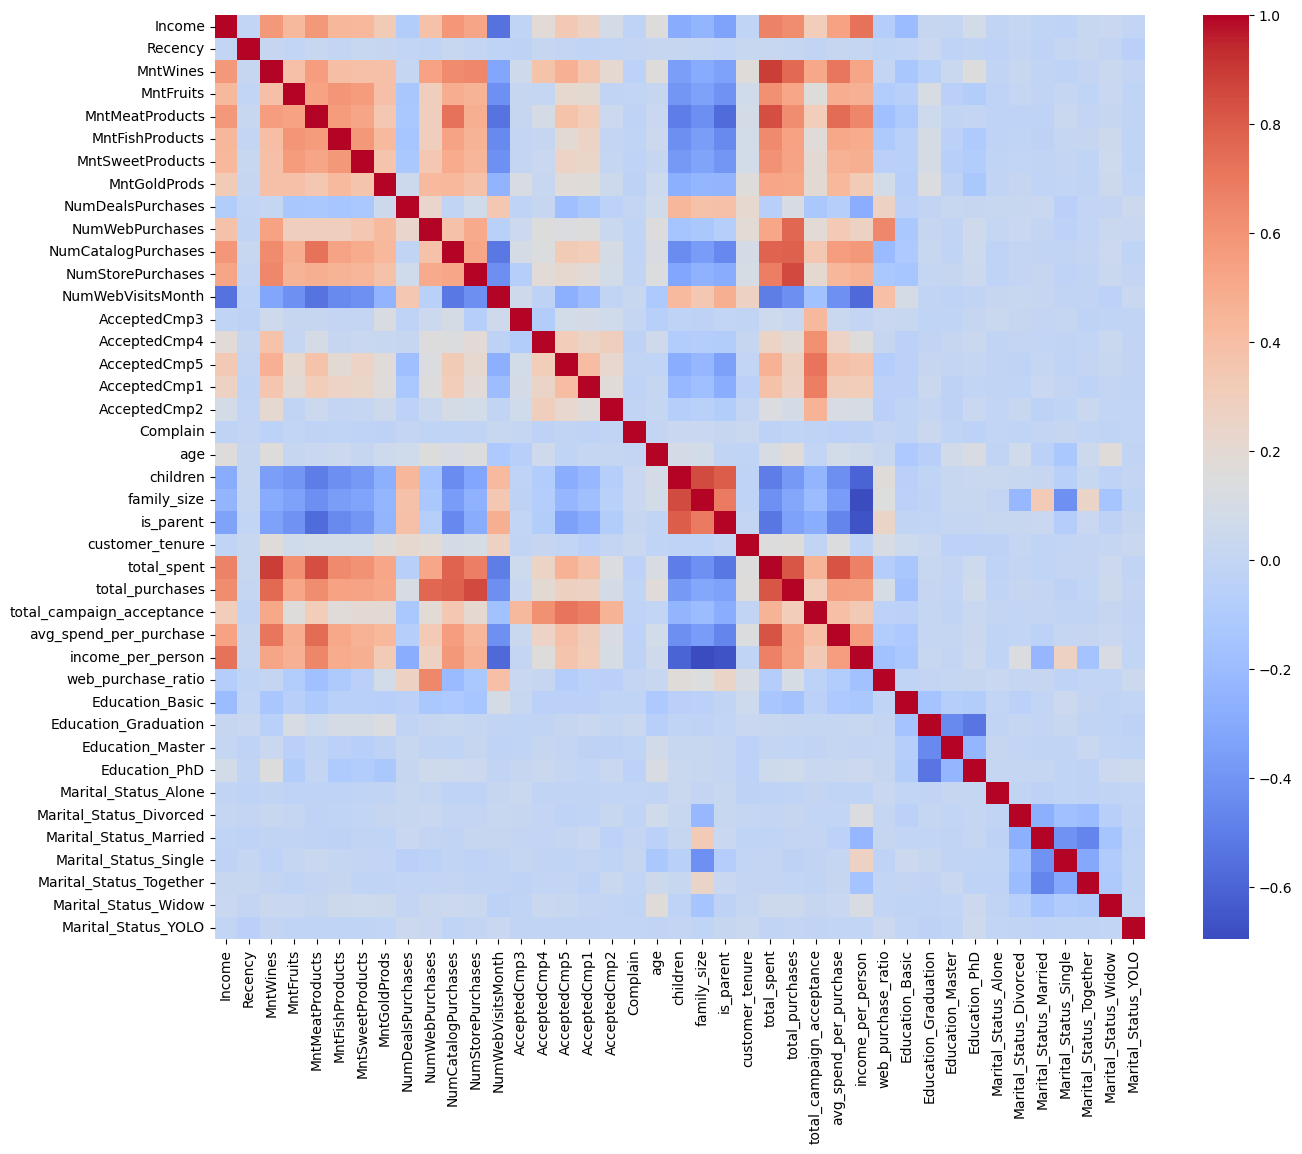

In [60]:
plt.figure(figsize=(15,12))

sns.heatmap(
    X.corr(),
    cmap="coolwarm"
)

plt.show()

In [61]:
corr = X.corr().abs()

upper = corr.where(
    np.triu(np.ones(corr.shape),k=1).astype(bool)
)

high_corr = [
    column
    for column in upper.columns
    if any(upper[column] > 0.90)
]

print(high_corr)

[]


In [62]:
alpha = 0.05

chi2_scores, p_values = chi2(X, y)

chi2_df = pd.DataFrame({
    "Feature": X.columns,
    "Chi2 Score": chi2_scores,
    "P-Value": p_values
})

chi2_df["Decision"] = chi2_df["P-Value"].apply(
    lambda p: "Keep" if p < alpha else "Drop"
)

chi2_df = chi2_df.sort_values(by="P-Value")

chi2_df

,Feature,Chi2 Score,P-Value,Decision
0,Income,4.758246e+05,0.000000e+00,Keep
27,avg_spend_per_purchase,3.570031e+03,0.000000e+00,Keep
24,total_spent,9.440887e+04,0.000000e+00,Keep
28,income_per_person,2.821735e+06,0.000000e+00,Keep
7,MntGoldProds,2.727618e+03,0.000000e+00,Keep
6,MntSweetProducts,1.940269e+03,0.000000e+00,Keep
23,customer_tenure,9.737855e+03,0.000000e+00,Keep
4,MntMeatProducts,3.819977e+04,0.000000e+00,Keep
3,MntFruits,2.128216e+03,0.000000e+00,Keep
2,MntWines,5.099616e+04,0.000000e+00,Keep


In [63]:
drop_features = [
    "Complain",
    "Marital_Status_YOLO",
    "Marital_Status_Alone"
]

X = X.drop(columns=drop_features)

print(X.shape)

(2237, 38)


# MODEL

In [64]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [65]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [66]:
base_models_dic = {'lr_base_model': LogisticRegression(), 'knn_base_model': KNeighborsClassifier(), 'svc_base_model': SVC(), 'nv_base_model': GaussianNB(), 'dt_base_model': DecisionTreeClassifier(random_state=42), 'rf_base_model': RandomForestClassifier(random_state= 42, n_estimators=100)}
base_models_accuracy = {}
base_models_score = {}
base_models_con_matrix = {}


In [67]:
for name, base_model in base_models_dic.items():
    if name in ['lr_base_model', 'knn_base_model', 'svc_base_model']:
        base_model.fit(x_train_scaled, y_train)
        y_predict = base_model.predict(x_test_scaled)
        base_models_accuracy[name] = accuracy_score(y_test, y_predict)
        base_models_con_matrix[name] = confusion_matrix(y_test, y_predict)
        base_models_score[name] = base_model.score(x_train_scaled, y_train)
    else:
        base_model.fit(x_train, y_train)
        y_predict = base_model.predict(x_test)
        base_models_accuracy[name] = accuracy_score(y_test, y_predict)
        base_models_con_matrix[name] = confusion_matrix(y_test, y_predict)
        base_models_score[name] = base_model.score(x_train, y_train)

In [68]:
base_models_df = pd.DataFrame({
    'Accuracy': base_models_accuracy,
    'Confusion_Matrix': base_models_con_matrix,
    'Score': base_models_score,
}).sort_values(by= 'Accuracy', ascending=False)
base_models_df

,Accuracy,Confusion_Matrix,Score
lr_base_model,0.901786,"[[371, 10], [34, 33]]",0.907211
svc_base_model,0.883929,"[[374, 7], [45, 22]]",0.926775
rf_base_model,0.883929,"[[371, 10], [42, 25]]",0.994969
knn_base_model,0.866071,"[[367, 14], [46, 21]]",0.902739
dt_base_model,0.837054,"[[349, 32], [41, 26]]",0.994969
nv_base_model,0.787946,"[[314, 67], [28, 39]]",0.767468


In [69]:
import joblib
joblib.dump(base_models_dic['lr_base_model'], 'campaign_response_lr_model.pkl')
joblib.dump(scaler, 'campaign_response_scale.pkl')

['campaign_response_scale.pkl']